### Data Preprocessing. 

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib    
import os  

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
)
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    confusion_matrix,
)
 

In [3]:
df = pd.read_csv('Loan_default.csv')

In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
#checking the dataset shape and info
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

Dataset Shape: (255347, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner  

In [6]:
#describing our data 
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [7]:
#checking for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [8]:
df.drop(columns=['LoanID'], inplace=True)

In [9]:
print("\nMissing Values:")
print(df.isnull().sum())
print()

# Determine categorical and numeric columns
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
numeric_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

print('Categorical columns:', categorical_cols)
print('Numeric columns:', numeric_cols)


Missing Values:
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Categorical columns: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
Numeric columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']


In [10]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


Default
0    225694
1     29653
Name: count, dtype: int64


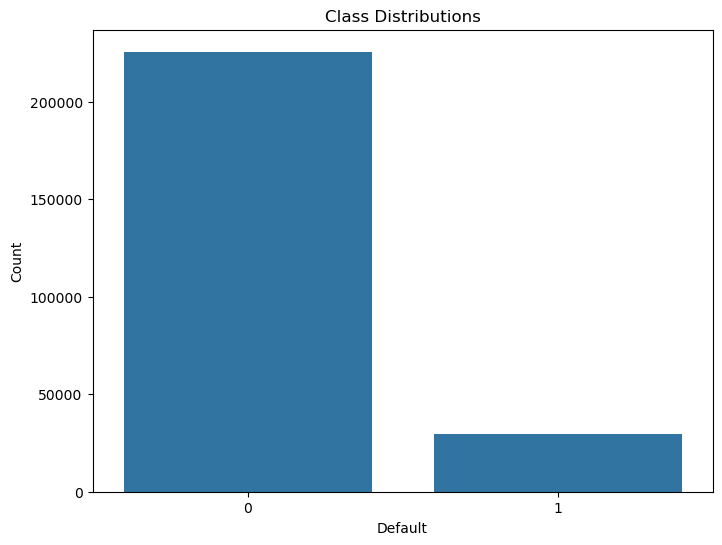

In [11]:
#checking if dataset has a class imbalance
target_column = df['Default'].value_counts()
print(target_column)  

plt.figure(figsize=(8, 6))
sns.countplot(x='Default', data=df)
plt.title('Class Distributions')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

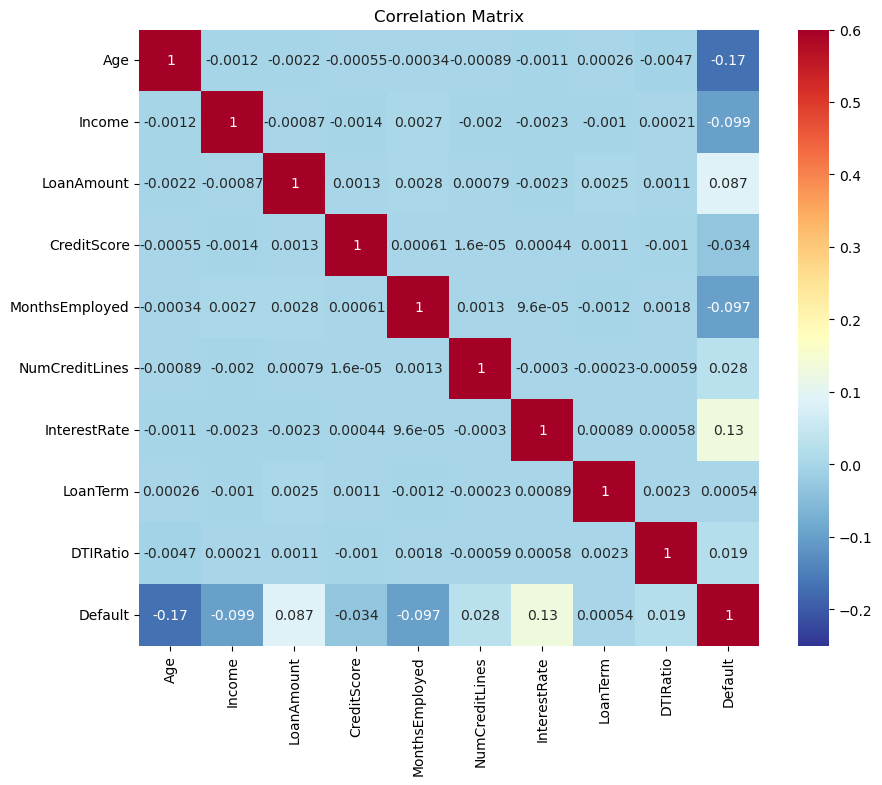

In [12]:
cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio','Default']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot=True, vmax = 0.6)
plt.title('Correlation Matrix')
plt.show()

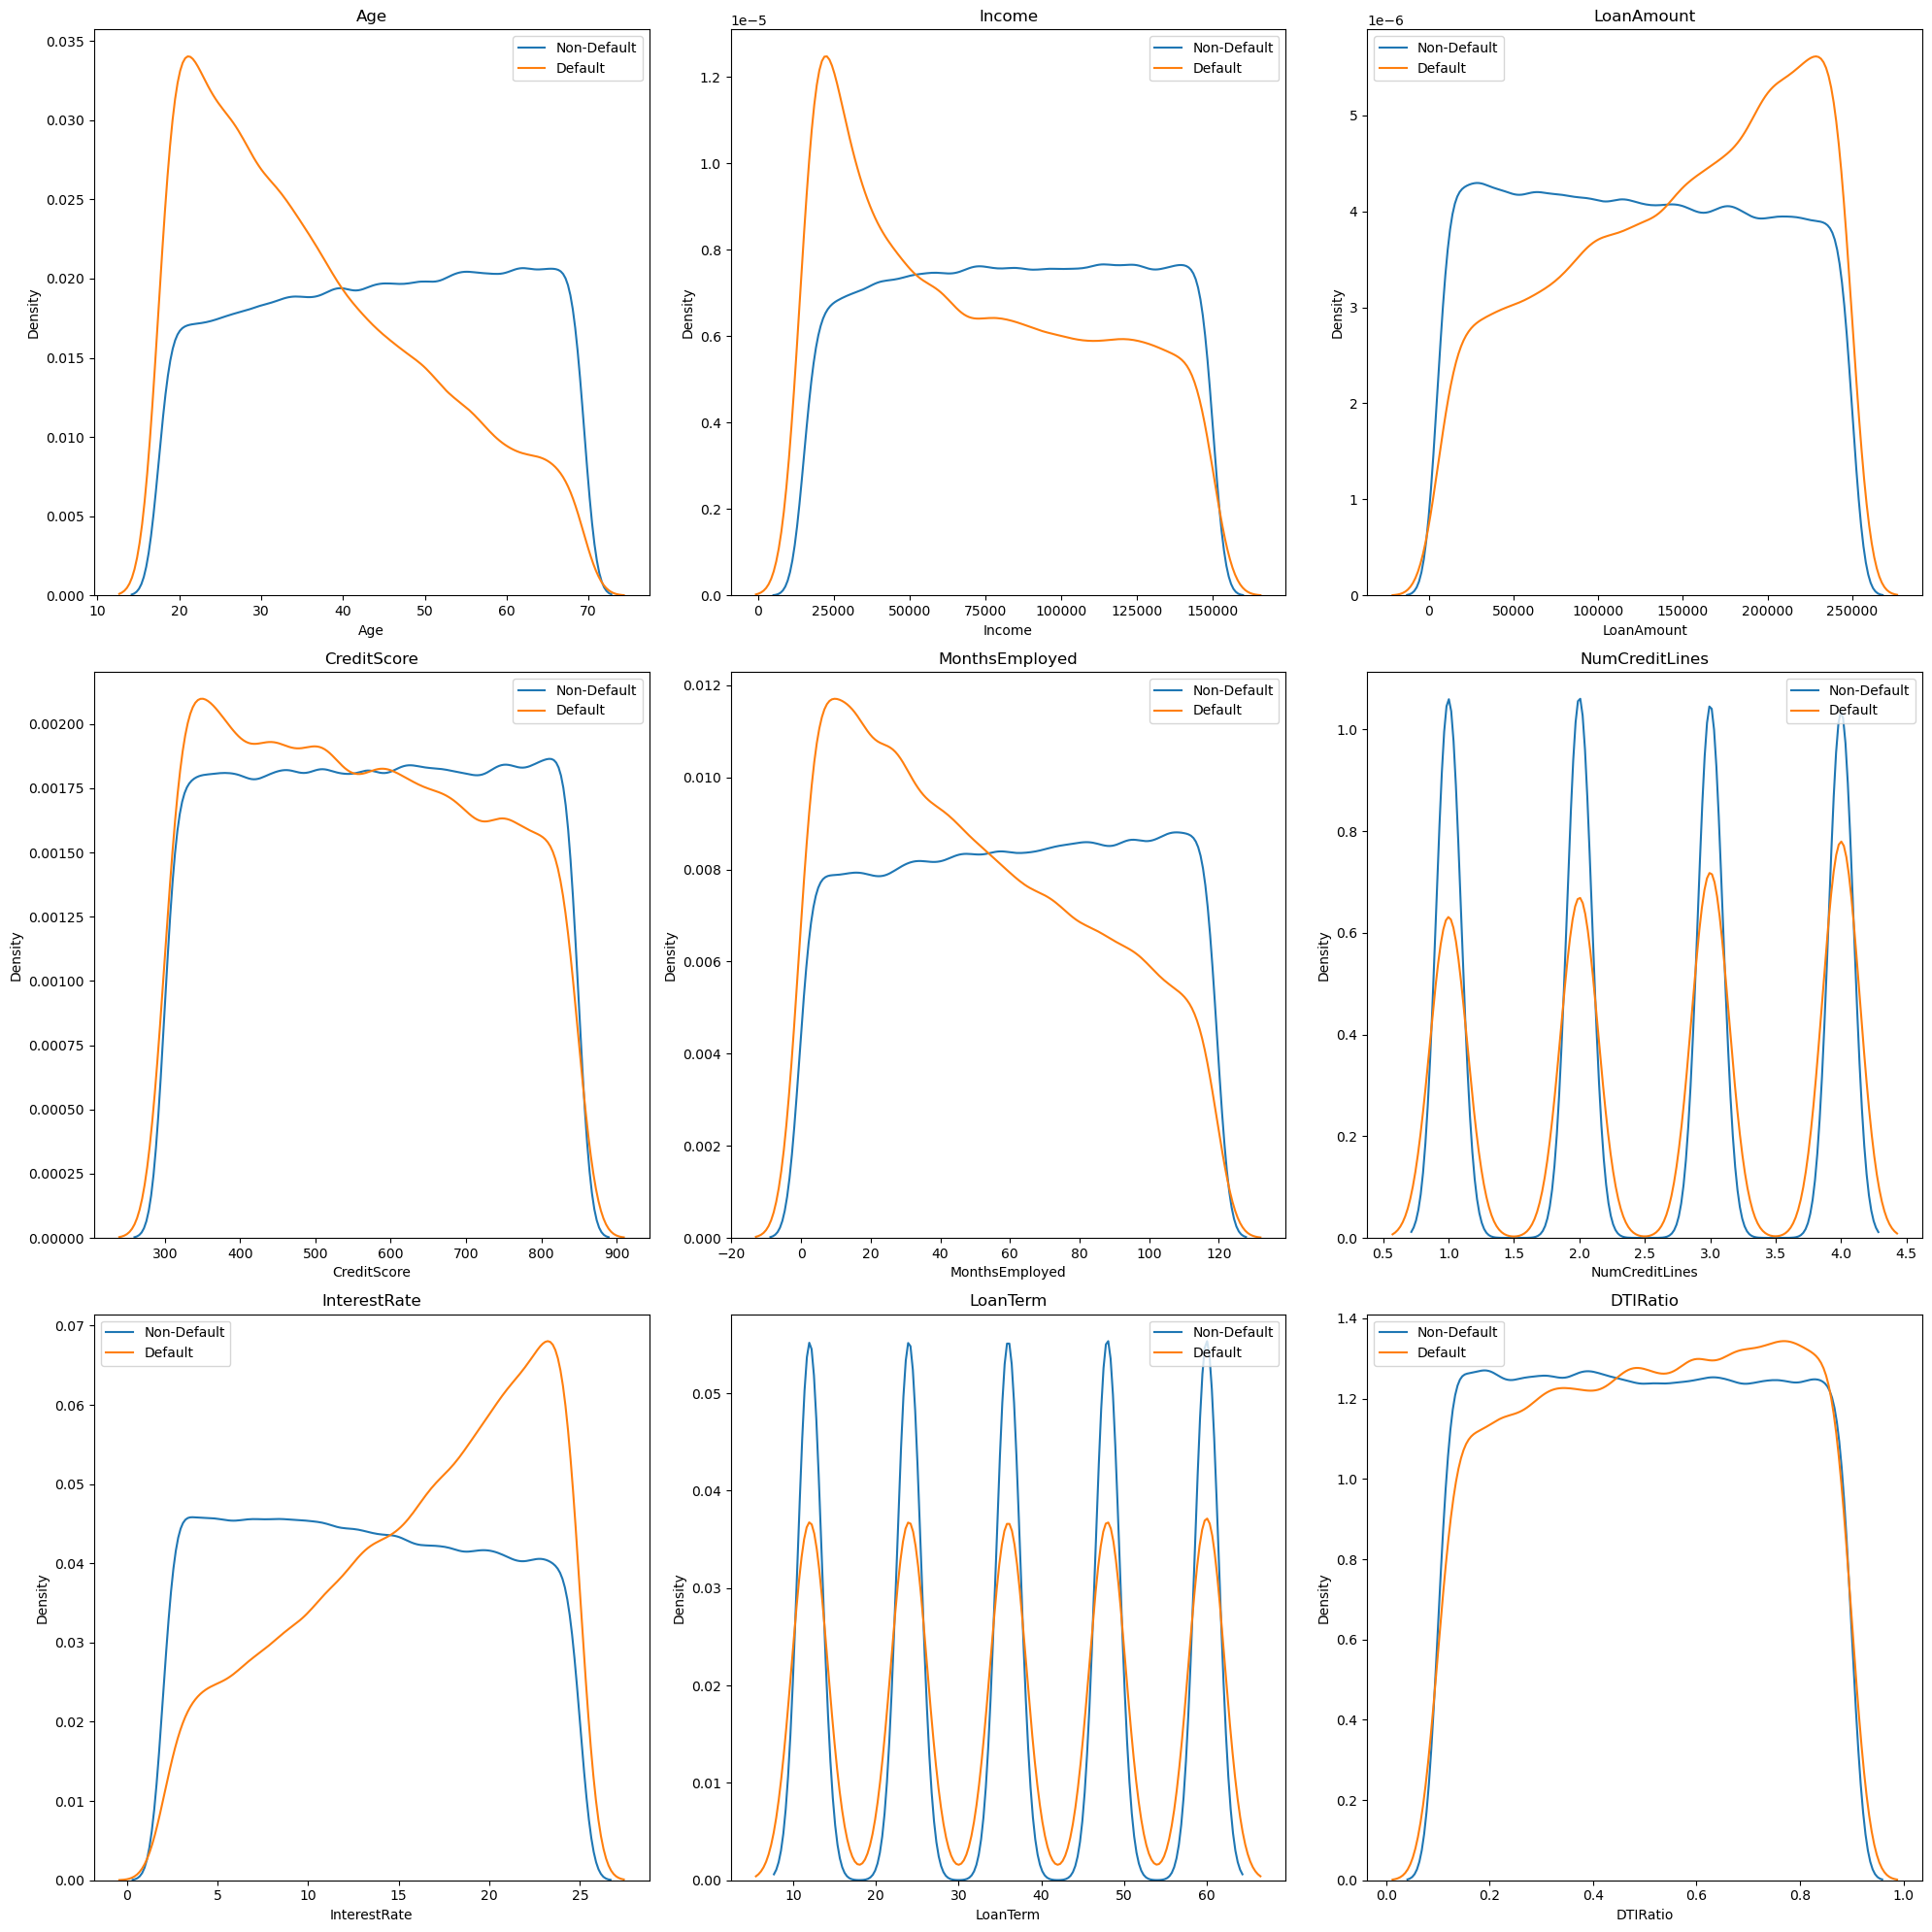

In [13]:
#Feature distribution of the numeric cols with a KDE plot
fig, axes = plt.subplots(3, 3, figsize=(20, 20))
axes = axes.ravel()

#exclude the default col
for idx, col in enumerate([c for c in numeric_cols if c != 'Default']):
    sns.kdeplot(data=df[df['Default']==0][col], label='Non-Default', ax=axes[idx])
    sns.kdeplot(data=df[df['Default']==1][col], label='Default', ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].legend()

plt.tight_layout()
plt.show()

<Axes: ylabel='Density'>

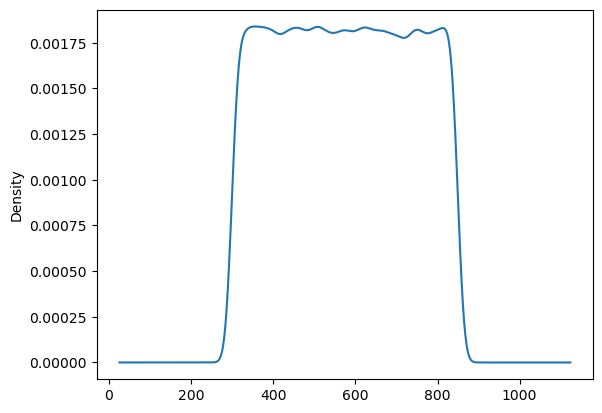

In [14]:
df['CreditScore'].plot(kind='kde')

In [14]:
# frequency distribution 
for col in df.select_dtypes(exclude='number').columns:
    if col == 'Default':
        continue
    print(f"\n {col}\n")
    print(df.groupby(col)['Default'].value_counts())


 Education

Education    Default
Bachelor's   0          56577
             1           7789
High School  0          55673
             1           8230
Master's     0          56633
             1           6908
PhD          0          56811
             1           6726
Name: count, dtype: int64

 EmploymentType

EmploymentType  Default
Full-time       0          57632
                1           6024
Part-time       0          56484
                1           7677
Self-employed   0          56404
                1           7302
Unemployed      0          55174
                1           8650
Name: count, dtype: int64

 MaritalStatus

MaritalStatus  Default
Divorced       0          74376
               1          10657
Married        0          76433
               1           8869
Single         0          74885
               1          10127
Name: count, dtype: int64

 HasMortgage

HasMortgage  Default
No           0          111909
             1           15761
Yes         

In [15]:
#checking for outliers 
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary[col] = len(outliers)

pd.Series(outlier_summary).sort_values(ascending=False)

Default           29653
Age                   0
Income                0
LoanAmount            0
MonthsEmployed        0
CreditScore           0
NumCreditLines        0
InterestRate          0
LoanTerm              0
DTIRatio              0
dtype: int64

In [16]:
df[numeric_cols].skew().sort_values(ascending=False)
#result is that our columns are not heavily skewed, so no need for log transformation
#default column is expected

Default           2.396377
CreditScore       0.004688
InterestRate      0.004608
Age               0.000698
NumCreditLines   -0.000278
Income           -0.000381
DTIRatio         -0.001499
LoanAmount       -0.001827
MonthsEmployed   -0.002142
LoanTerm         -0.002178
dtype: float64

In [17]:
X = df.drop(columns=['Default'])
y = df['Default']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train:      {len(X_train):,} ({len(X_train)/len(X):.0%})")
print(f"Validation: {len(X_val):,}   ({len(X_val)/len(X):.0%})")
print(f"Test:       {len(X_test):,}   ({len(X_test)/len(X):.0%})")
print(f"\nTrain default rate:      {y_train.mean():.2%}")
print(f"Validation default rate: {y_val.mean():.2%}")
print(f"Test default rate:       {y_test.mean():.2%}")

Train:      178,742 (70%)
Validation: 38,302   (15%)
Test:       38,303   (15%)

Train default rate:      11.61%
Validation default rate: 11.61%
Test default rate:       11.61%


In [18]:
class LoanEncoder(BaseEstimator, TransformerMixin):
    """
    Handles:
      - Binary mapping   : Yes/No columns  to 1 / 0
      - Ordinal encoding : Education levels
      - One-Hot encoding : EmploymentType, MaritalStatus, LoanPurpose
    """
 
    def __init__(
        self,
        binary_cols=None,
        education_map=None,
        ohe_cols=None,
    ):
        self.binary_cols = binary_cols or ['HasMortgage', 'HasDependents', 'HasCoSigner']
        self.education_map = education_map or {
            'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3
        }
        self.ohe_cols = ohe_cols or ['EmploymentType', 'MaritalStatus', 'LoanPurpose']
 
    def fit(self, X, y=None):
        X_ = self._apply_binary(X.copy())
        X_ = self._apply_ordinal(X_)
 
        
        self.ohe_ = OneHotEncoder(
            drop='first',           
            sparse_output=False,
            handle_unknown='ignore' 
        )
        self.ohe_.fit(X_[self.ohe_cols])
        self.ohe_feature_names_ = self.ohe_.get_feature_names_out(self.ohe_cols).tolist()
        return self
 
    def transform(self, X, y=None):
        X_ = self._apply_binary(X.copy())
        X_ = self._apply_ordinal(X_)
 
        
        ohe_array = self.ohe_.transform(X_[self.ohe_cols])
        ohe_df    = pd.DataFrame(ohe_array, columns=self.ohe_feature_names_, index=X_.index)
 
        X_ = X_.drop(columns=self.ohe_cols)
        X_ = pd.concat([X_, ohe_df], axis=1)
 
       
        bool_cols = X_.select_dtypes(include='bool').columns
        X_[bool_cols] = X_[bool_cols].astype(int)
 
        return X_
 
    
    #private helpers
    def _apply_binary(self, X_):
        for col in self.binary_cols:
            X_[col] = X_[col].map({'Yes': 1, 'No': 0})
        return X_
 
    def _apply_ordinal(self, X_):
        X_['Education'] = X_['Education'].map(self.education_map)
        return X_

In [19]:
pipeline = Pipeline(steps=[
    ('encoder', LoanEncoder()),
    ('model',   RandomForestClassifier(
                    class_weight='balanced',
                    n_estimators=200,
                    random_state=42,
                    n_jobs=-1
                ))
])

In [20]:
pipeline.fit(X_train, y_train)
 
n_features = len(pipeline.named_steps['encoder'].ohe_feature_names_) + \
             len(pipeline.named_steps['encoder'].binary_cols) + \
             1
print(f"\nBaseline pipeline fitted — features after encoding: {pipeline[0].transform(X_train).shape[1]}")


Baseline pipeline fitted — features after encoding: 22


In [21]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
 
cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'precision', 'recall'],
    n_jobs=-1,
)
 
print("\nCross-Validation Results(threshold = 0.50)")
print("-" * 50)
for metric in ['roc_auc', 'f1', 'precision', 'recall']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:12}: {scores.mean():.4f}  (+/- {scores.std():.4f})")


Cross-Validation Results(threshold = 0.50)
--------------------------------------------------
  roc_auc     : 0.7344  (+/- 0.0017)
  f1          : 0.0250  (+/- 0.0035)
  precision   : 0.6940  (+/- 0.0263)
  recall      : 0.0127  (+/- 0.0018)


In [23]:
param_dist = {
    'model__n_estimators'     : [100, 200],
    'model__max_depth'        : [None, 10, 20],
    'model__min_samples_leaf' : [1, 5, 10],
    'model__max_features'     : ['sqrt', 'log2'],
    'model__class_weight'     : ['balanced', 'balanced_subsample'],
}
 
search = RandomizedSearchCV(
    estimator  = pipeline,       
    param_distributions = param_dist,
    n_iter     = 10,             
    scoring    = 'roc_auc',
    cv         = cv,             
    n_jobs     = -1,
    random_state = 42,
    verbose    = 1,              
    refit      = True,           
)
 
search.fit(X_train, y_train)
 
print("\nHyperparameter Search")
print("-" * 50)
print(f"  Best CV ROC-AUC : {search.best_score_:.4f}")
print(f"  Best params     :")
for param, value in search.best_params_.items():
    print(f"    {param.replace('model__', ''):30}: {value}")
 
best_pipeline = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Hyperparameter Search
--------------------------------------------------
  Best CV ROC-AUC : 0.7434
  Best params     :
    n_estimators                  : 100
    min_samples_leaf              : 1
    max_features                  : log2
    max_depth                     : 10
    class_weight                  : balanced


In [25]:
val_probs = best_pipeline.predict_proba(X_val)[:, 1]
val_preds_50 = (val_probs >= 0.50).astype(int)
print("\nValidation Set: threshold 0.50")
print("-" * 50)
print(classification_report(y_val, val_preds_50, target_names=['No Default', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_val, val_probs):.4f}")


Validation Set: threshold 0.50
--------------------------------------------------
              precision    recall  f1-score   support

  No Default       0.94      0.75      0.83     33854
     Default       0.24      0.61      0.35      4448

    accuracy                           0.74     38302
   macro avg       0.59      0.68      0.59     38302
weighted avg       0.86      0.74      0.78     38302

ROC-AUC: 0.7506



Best threshold : 0.54
Best val F1    : 0.3608


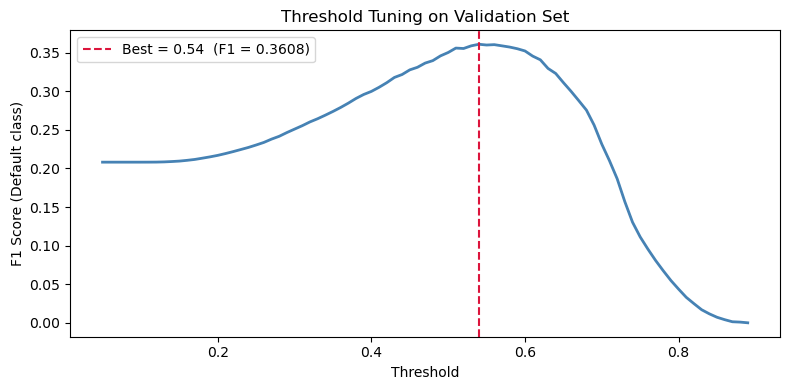

In [26]:
#threshold tuning
thresholds = np.arange(0.05, 0.90, 0.01)
f1_scores  = [f1_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]
 
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
 
print(f"\nBest threshold : {best_threshold:.2f}")
print(f"Best val F1    : {best_f1:.4f}")
 
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='steelblue', linewidth=2)
plt.axvline(best_threshold, color='crimson', linestyle='--',
            label=f'Best = {best_threshold:.2f}  (F1 = {best_f1:.4f})')
plt.xlabel('Threshold')
plt.ylabel('F1 Score (Default class)')
plt.title('Threshold Tuning on Validation Set')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Validation results at best threshold
val_preds_best = (val_probs >= best_threshold).astype(int)
print(f"\nValidation Set — threshold {best_threshold:.2f} (after tuning)")
print("-" * 50)
print(classification_report(y_val, val_preds_best, target_names=['No Default', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_val, val_probs):.4f}")
 


Validation Set — threshold 0.54 (after tuning)
--------------------------------------------------
              precision    recall  f1-score   support

  No Default       0.93      0.82      0.87     33854
     Default       0.28      0.52      0.36      4448

    accuracy                           0.78     38302
   macro avg       0.60      0.67      0.62     38302
weighted avg       0.85      0.78      0.81     38302

ROC-AUC: 0.7506


In [28]:
test_probs = best_pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_threshold).astype(int)
 
print(f"\nTest Set — threshold {best_threshold:.2f}")
print("=" * 50)
print(classification_report(y_test, test_preds, target_names=['No Default', 'Default']))
print(f"ROC-AUC: {roc_auc_score(y_test, test_probs):.4f}")
 
cm = confusion_matrix(y_test, test_preds)
print(f"\nConfusion Matrix:\n{cm}")
print(f"\n  True Negatives  (correctly predicted No Default) : {cm[0,0]:,}")
print(f"  False Positives (No Default predicted as Default) : {cm[0,1]:,}")
print(f"  False Negatives (Default missed)                  : {cm[1,0]:,}")
print(f"  True Positives  (Default correctly caught)        : {cm[1,1]:,}")


Test Set — threshold 0.54
              precision    recall  f1-score   support

  No Default       0.93      0.82      0.87     33855
     Default       0.28      0.53      0.36      4448

    accuracy                           0.79     38303
   macro avg       0.60      0.67      0.62     38303
weighted avg       0.85      0.79      0.81     38303

ROC-AUC: 0.7548

Confusion Matrix:
[[27727  6128]
 [ 2090  2358]]

  True Negatives  (correctly predicted No Default) : 27,727
  False Positives (No Default predicted as Default) : 6,128
  False Negatives (Default missed)                  : 2,090
  True Positives  (Default correctly caught)        : 2,358


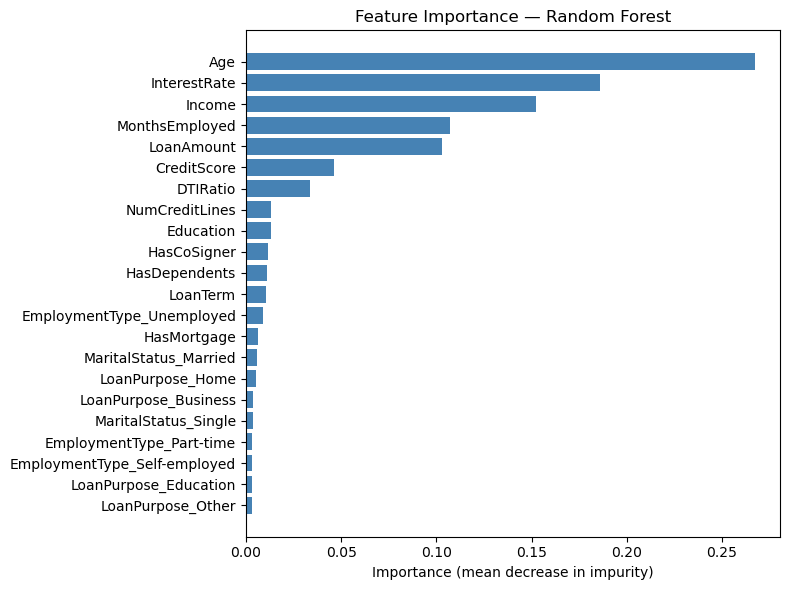

In [36]:
#feature importance 
encoder = best_pipeline.named_steps['encoder']
model = best_pipeline.named_steps['model']

X_train_encoded = encoder.transform(X_train)
feature_names = X_train_encoded.columns.tolist()
importances = model.feature_importances_

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=True)
)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance (mean decrease in impurity)')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

SHAP array shape     : (500, 22)
Feature names length : 22
OK, SHAP shapes match



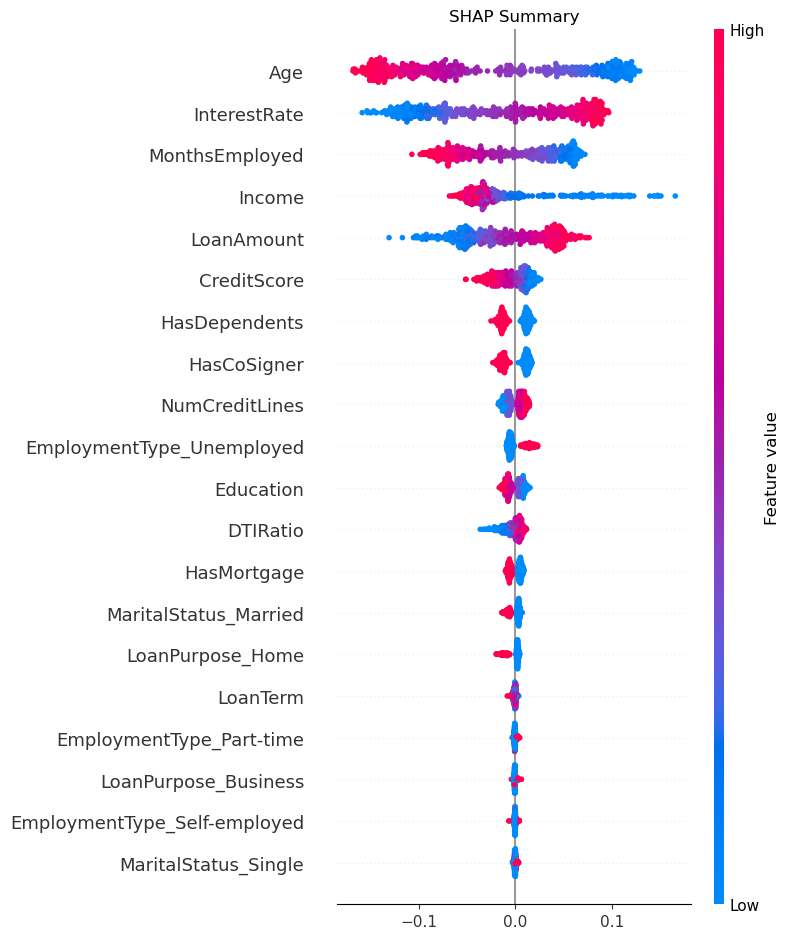

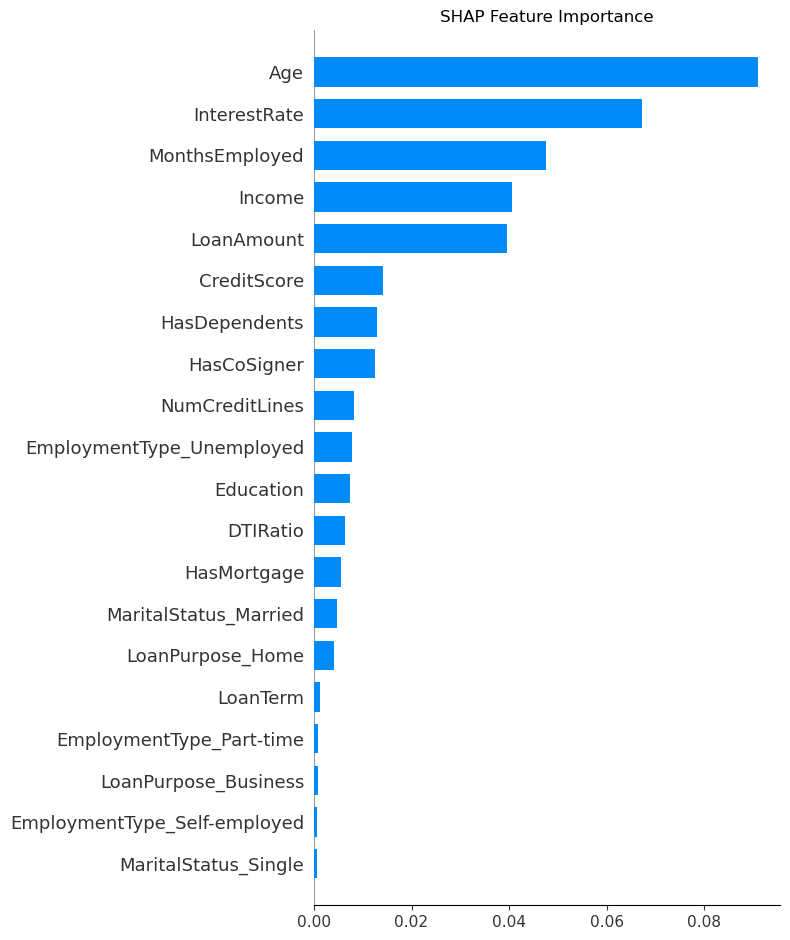

In [46]:
# SHAP on validation set
X_val_encoded = encoder.transform(X_val)

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_val_encoded), size=500, replace=False)
X_shap_sample = X_val_encoded.iloc[sample_idx].reset_index(drop=True)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_vals_default = shap_values[1]
else:
    shap_vals_default = shap_values[:, :, 1]

print(f"SHAP array shape     : {shap_vals_default.shape}")
print(f"Feature names length : {len(feature_names)}")
assert shap_vals_default.shape[1] == len(feature_names), \
    "SHAP column count does not match feature_names, check above"
print("OK, SHAP shapes match\n")

#beeswam plot
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_vals_default,
    X_shap_sample,
    feature_names=feature_names,
    show=False,
)

plt.gca().set_xlabel("")

plt.title('SHAP Summary')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

#bar 
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_vals_default,
    X_shap_sample,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
)

plt.gca().set_xlabel("")  

plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
encoder = best_pipeline.named_steps['encoder']
X_enc_sample = encoder.transform(X_train.iloc[[0]])
feature_names = X_enc_sample.columns.tolist()

model_bundle = {
    'pipeline': best_pipeline,
    'threshold': best_threshold,
    'feature_names': feature_names,
}

save_path = "model.pkl"
joblib.dump(model_bundle, save_path)


size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"Saved: {save_path} ({size_mb:.1f} MB)")

# Sanity test
bundle = joblib.load(save_path)
test_prob = bundle['pipeline'].predict_proba(X_test.iloc[[0]])[:, 1][0]
print(f"first test row default probability = {test_prob:.4f}")

Saved: model.pkl (13.3 MB)
first test row default probability = 0.2568
